### **Submission rules**:
1. The completed assignment should be prepared as s a Jupyter Notebook (.ipynb file). Please make a copy of this notebook for your team. Make sure you opened it via UCU email address. Submit the Jupyter Notebook (.ipynb file) to **lms**.
2. Please execute all the cells before submission; make sure there are no errors, everything has been generated, and all numerical answers calculated.
3. There should be only one submission per team. However, don't forget to choose a person from your team who would submit the task, and make sure that the names of all team members are listed in the notebook. Teammates not mentioned in the notebook will not be graded for this lab.
4. You also need to provide a work breakdown structure estimating the efforts of each team member. Please provide it at the top of your notebook. If you do not provide the work breakdown, the points will be reducted from your work.
5. The final deadline is specified on LMS.

**IMPORTANT**: If you submit your assignment after this time and date, it will not be graded.

### Work brakdown structure: ###
* SVD implementation, SVD of symmetric matrices - Bohdana Zubrytska
* Image compression using SVD - Zakhar Veresniuk
* DCT - Denys Marchenko
* Result - Teodor Talan

# Image compression with SVD

The singular value decomposition of a matrix A is the factorization of A into the
product of three matrices:
\begin{align}
 A = UDV^T,
 \end{align}
where the columns of U and V are orthonormal and
the matrix D is diagonal with positive real entries. The SVD is useful in many tasks. First, in many applications, the data matrix A is close to a
matrix of low rank and it is useful to find a low rank matrix which is a good approximation
to the data matrix. You will show that from the singular value decomposition of A, we can get the matrix B of rank k which best approximates A; in fact, we can do this for every
k. Also, singular value decomposition is defined for all matrices (rectangular or square) unlike spectral decomposition, although the latter one is used more commonly in Linear Algebra.

Considering that any image can be represented as a rectangular matrix, you can find the best rank k approximation of this image using SVD. The idea is that by significantly reducing the storage space, you can still preserve a very good quality of the image

In [8]:
import cv2 as cv
import numpy as np
from ipywidgets import interact, fixed
import ipywidgets as widget
import matplotlib.pyplot as plt


### SVD implementation (0.5)

Implement a function to compute SVD of the matrix.

Do not use the built-in functions; instead, compare your solution with the built-in one.

*Hint:* one of the simpliest methods for finding eigenvalues and eigenvectors of the matrix is [Power Iteration](https://en.wikipedia.org/wiki/Power_iteration). Hovewer, you may try some advanced methods :)

In [9]:
def power_iteration(M, num_iter=1000, tol=1e-10):
    """
    Find the dominant eigenvector of M using power iteration
    """
    n = M.shape[0]
    v = np.random.rand(n)
    v = v / np.linalg.norm(v)
    for _ in range(num_iter):
        v_new = M @ v
        norm = np.linalg.norm(v_new)
        if norm < tol:
            break
        v_new = v_new / norm
        if np.linalg.norm(v_new - v) < tol:
            v = v_new
            break
        v = v_new
    eigenvalue = float(v @ M @ v)
    return eigenvalue, v

def my_svd(A, tol=1e-10):
    """
    Compute full SVD of matrix A using power iteration.
    Returns U, s, Vt such that A ≈ U @ np.diag(s) @ Vt
    """
    m, n = A.shape
    AtA = A.T @ A
    rank = np.linalg.matrix_rank(A)

    singular_values = []
    V_cols = []
    residual = AtA.copy()

    for _ in range(rank):
        eigval, v = power_iteration(residual)
        if eigval < tol:
            break
        sigma = np.sqrt(abs(eigval))
        singular_values.append(sigma)
        V_cols.append(v)
        # deflate
        residual = residual - eigval * np.outer(v, v)

    singular_values = np.array(singular_values)
    V = np.column_stack(V_cols)  # n x r

    U_cols = []
    for i in range(len(singular_values)):
        u = A @ V[:, i] / singular_values[i]
        U_cols.append(u)
    U = np.column_stack(U_cols)  # m x r

    return U, singular_values, V.T


B = np.random.rand(5, 4)
U_mine, s_mine, Vt_mine = my_svd(B)
U_np, s_np, Vt_np = np.linalg.svd(B, full_matrices=False)
print("Max diff in singular values:", np.max(np.abs(np.sort(s_mine)[::-1] - s_np)))
print("Reconstruction error (my SVD):", np.linalg.norm(B - U_mine @ np.diag(s_mine) @ Vt_mine))

Max diff in singular values: 4.440892098500626e-16
Reconstruction error (my SVD): 1.6848181619073152e-10


Explain in detailes the chosen method for finding SVD.


---
We used Power Iteration on A^T A matrix.

The idea is that if we have A^T A (which is symmetric and positive semidefinite), its eigenvalues are exactly the squares of singular values of A, and eigenvectors are the right singular vectors V. So instead of doing SVD directly, I just need to find eigenvalues/eigenvectors of A^T A.

Power iteration works like this: take a random vector, multiply by the matrix, normalize, repeat. After enough iterations it converges to the eigenvector corresponding to the largest eigenvalue. Then sigma = sqrt(eigenvalue), and the left singular vector u = A @ v / sigma.

To find the next singular value I do deflation: subtract the rank-1 matrix sigma^2 * v * v^T from A^T A and repeat the whole process. Each time we get the next largest singular value.

---



Explain why finding the roots of characteristic polynomial for finding eigenvalues is not always the best choice.

---


- For large matrices, computing det(A - λI) is numerically unstable and extremely slow (O(n!)).
- Polynomial root-finding algorithms diverge or give complex roots due to floating point errors.
- Power iteration is simple, stable, and works well in practice.


---


### SVD of symmetric matrices (0.5 pts)

Here you have a symmetric matrix A. Compute a full SVD of this matrix.

In [10]:
A = np.array([[1, 2, 3, 4], [2, 7, 4, 5], [3, 4, 3, 8], [4, 5, 8, 3]] , dtype=float)

U, s, Vt = np.linalg.svd(A)
print("\nSymmetric matrix A SVD:")
print("U:\n", np.round(U, 4))
print("Singular values:", np.round(s, 4))
print("Vt:\n", np.round(Vt, 4))

eigenvalues, eigenvectors = np.linalg.eigh(A)
idx = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("\nEigenvalues:", np.round(eigenvalues, 4))
print("Are singular values == |eigenvalues|?", np.allclose(s, np.abs(eigenvalues)))


Symmetric matrix A SVD:
U:
 [[-0.3046 -0.149   0.313   0.8872]
 [-0.5424 -0.0713 -0.8317  0.0952]
 [-0.5343 -0.6433  0.3559 -0.4171]
 [-0.5723  0.7476  0.2894 -0.173 ]]
Singular values: [17.3385  5.1584  2.7957  0.9758]
Vt:
 [[-0.3046 -0.5424 -0.5343 -0.5723]
 [ 0.149   0.0713  0.6433 -0.7476]
 [ 0.313  -0.8317  0.3559  0.2894]
 [-0.8872 -0.0952  0.4171  0.173 ]]

Eigenvalues: [17.3385 -5.1584  2.7957 -0.9758]
Are singular values == |eigenvalues|? True


#### Explain what matrices did you get as a result. What can you say about singular values of this matrix (about its eigenvalues)?

U is an orthogonal matrix whose columns are left singular vectors.
Vt is just V transposed, also orthogonal, columns of V are right singular vectors.
s contains singular values [17.34, 5.16, 2.80, 0.98].

Since A is symmetric, U and V turned out to be equal (up to sign in some columns).
This makes sense because for symmetric matrices A^T A = A^2, so left and right
singular vectors are basically the same thing.

About singular values: they are always non-negative by definition.
Here we can see that singular values are exactly the absolute values of eigenvalues.
Eigenvalues of A are [17.34, -5.16, 2.80, -0.98] — some are negative.
But singular values are [17.34, 5.16, 2.80, 0.98] — all positive, just |eigenvalues|.
This is always true for symmetric matrices.

#### How $SVD$ relates to matrises $Q, D, Q^T$ in spectral decomposition of this matrix? Are they identical? If they are, can you say that SVD of symmetric matrices always corresponds to its spectral decomposition? If not, then is it possible to find such symmetric matrises that SVD and spectral decomposition are identical?

Spectral decomposition gives A = Q D Q^T where D contains eigenvalues (can be negative).
SVD gives A = U S V^T where S contains singular values (always positive).

They are NOT identical here because A has negative eigenvalues (-5.16 and -0.98).
SVD handles this by flipping the sign of corresponding columns in U,
so the product still works out correctly.

They would be identical only if A is symmetric AND positive definite
(meaning all eigenvalues are strictly positive).
In that case eigenvalues == singular values, Q == U == V, and D == S.
For example, A = [[2, 1], [1, 3]] has eigenvalues 1.27 and 3.73, both positive,
so its SVD and spectral decomposition are exactly the same.

### Image compression using SVD (1 pts)

Upload the picture of a dog.

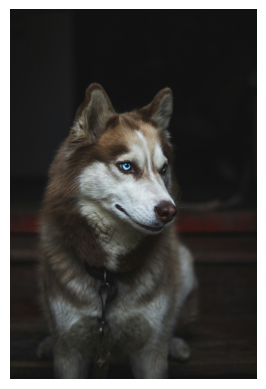

In [11]:
path = "haski.jpg"
image = cv.imread(path)
img_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis('off')
plt.show()

Complete the below function for finding a reduced SVD of a given matrix. (You may use the functions for finding eigenvalues of the matrix). Highlight the key differences between SVD and the reduced version of it.

In [12]:
def reduced_svd(A):
  '''
  Input: any matrix A
  Returns: tuple of matrix U, array of singular values and matrix V.T
  '''
  m, n = A.shape
  AtA = A.T @ A
  eigvals, V = np.linalg.eigh(AtA)
  idx = np.argsort(eigvals)[::-1]
  eigvals = eigvals[idx]
  V = V[:, idx]
  tol = max(m, n) * np.finfo(float).eps * np.max(np.abs(eigvals))
  rank = np.sum(eigvals > tol)
  eigvals = eigvals[:rank]
  V = V[:, :rank]
  singular_values = np.sqrt(eigvals)
  U = A @ V / singular_values
  return U, singular_values, V.T

The reduced $SVD$ basically chops off all the unimportant data: if a matrix $A$ is of rank $r$, it has only $r$ positive singular values. Other are zeros.
Thus, the reduced $SVD$ gets rid of those zero values $\sigma_i$ and corresponding left and right singular vectors that results in $m \times r$ matrix $U$,
$r \times r$ matrix $\Sigma$ and $r \times n$ matrix $V^T$.

Inspite of that, the reduced $SVD$ still returns us the matrix $A$!

Complete the function below. It should output the k-rank approximation of the given image using previously written SVD function. Use the slider to see how the image quality changes as we increase/decrease k.

For simplification, you can convert your image to a grayscale. However, it will be appreciated if you work with RGB channels (it is possible that you'll need to modify the method below a little).

In [13]:
_svd_cache = [np.linalg.svd(image[:, :, i].astype(float), full_matrices=False) for i in range(3)]

@interact(k=widget.IntSlider(min=1, max=np.linalg.matrix_rank(image[:, :, 0]), value=100), image=fixed(image))
def k_rank_compressed_image(k, image):
    approximated = np.zeros_like(image, dtype=float)
    for i in range(3):
        U, s, Vt = _svd_cache[i]
        approximated[:, :, i] = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    approximated = np.clip(approximated, 0, 255).astype(np.uint8)
    approximated_rgb = cv.cvtColor(approximated, cv.COLOR_BGR2RGB)
    plt.imshow(approximated_rgb)
    plt.axis('off')
    plt.show()

interactive(children=(IntSlider(value=100, description='k', max=4000, min=1), Output()), _dom_classes=('widget…

In general, compressing the image to 60-80% percent of its original size  lowers its quality but human eye won't be even able to notice it. Therefore, we can win in storage while keeping almost the same image quality. Find out the range of $k$'s which result in keeping only 60-80% of the size of the original image. For what $k$'s there is no reason to use SVD for the sake of reducing storage space?

In [14]:
def compressed_size(k, image):
  size_comp = 0
  m, n = image.shape[:2]
  channels = image.shape[2] if image.ndim == 3 else 1
  size_comp = channels * (m * k + k + k * n)
  return size_comp

In [15]:
lower_bound_k = upper_bound_k = compression_limit = 0
m, n = image.shape[:2]
channels = image.shape[2] if image.ndim == 3 else 1
original_size = m * n * channels
max_k = min(m, n)

valid_ks = [k for k in range(1, max_k + 1) if 0.6 <= compressed_size(k, image) / original_size <= 0.8]
lower_bound_k = min(valid_ks)
upper_bound_k = max(valid_ks)
compression_limit = next(k for k in range(1, max_k + 1) if compressed_size(k, image) >= original_size)

print("Range of k for 60-80% compression:", lower_bound_k, "-", upper_bound_k)
print("It makes no sense for compression with SVD for k more than:", compression_limit)

Range of k for 60-80% compression: 1440 - 1919
It makes no sense for compression with SVD for k more than: 2400


### Results (1 pt)
Choose some metric for determining how good the compression with SVD is. Experiment with other compression algorithms (DCT, for instance). Explain the chosen method(-s) for compession. Compare it with SVD. Be creative;)

SVD Compression (k=2): PSNR=22.91, SSIM=0.879
DCT Compression (k=2): PSNR=39.12, SSIM=0.954


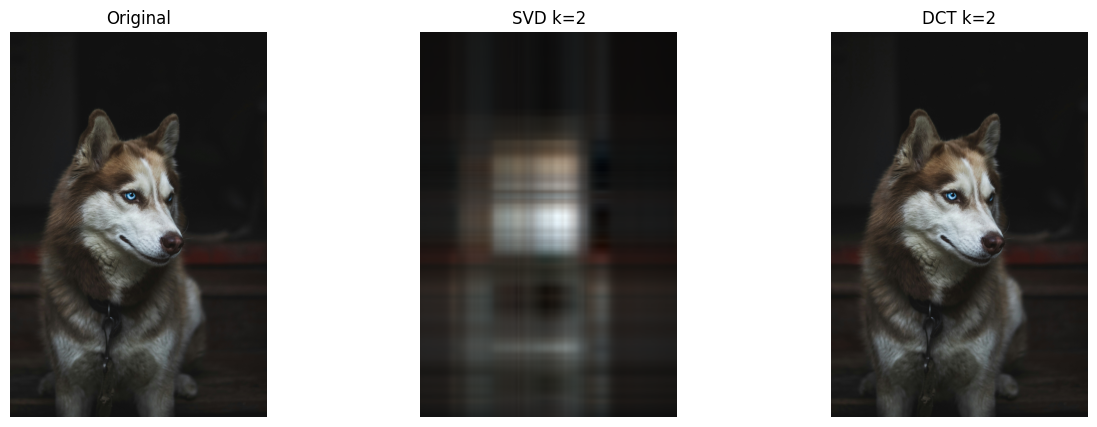

In [17]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import scipy.fftpack as fftpack

def psnr_ssim(original, compressed):
    psnr = 0
    ssim = 0
    for i in range(3):
        psnr += peak_signal_noise_ratio(original[:,:,i], compressed[:,:,i], data_range=255)
        ssim += structural_similarity(original[:,:,i], compressed[:,:,i], data_range=255)
    return psnr/3, ssim/3

def dct2(a):
    return fftpack.dct(fftpack.dct(a.T, norm='ortho').T, norm='ortho')

def idct2(a):
    return fftpack.idct(fftpack.idct(a.T, norm='ortho').T, norm='ortho')


def dct_compress_channel(channel, k):
    dct = dct2(channel)
    m, n = dct.shape
    mask = np.zeros_like(dct)
    mask[:k, :k] = 1
    dct = dct * mask
    return np.clip(idct2(dct), 0, 255)

def dct_compress_block(image, k, block_size=8):
    h, w = image.shape[:2]
    new_img = np.zeros_like(image, dtype=float)
    
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = image[i:i+block_size, j:j+block_size]
            if block.shape != (block_size, block_size): continue
            
            d = dct2(block)
            mask = np.zeros_like(d)
            mask[:k, :k] = 1 
            new_img[i:i+block_size, j:j+block_size] = idct2(d * mask)
            
    return new_img

def dct_compress_image(image, k, block_size=8):
    compressed = np.zeros_like(image, dtype=float)
    for i in range(3):
        compressed[:,:,i] = dct_compress_block(image[:,:,i], k, block_size)
    return compressed.astype(np.uint8)

k = 2
svd_approx = np.zeros_like(image, dtype=float)
for i in range(3):
    U, s, Vt = _svd_cache[i]
    svd_approx[:,:,i] = U[:,:k] @ np.diag(s[:k]) @ Vt[:k,:]
svd_approx = np.clip(svd_approx, 0, 255).astype(np.uint8)

dct_approx = dct_compress_image(image, k)

psnr_svd, ssim_svd = psnr_ssim(image, svd_approx)
psnr_dct, ssim_dct = psnr_ssim(image, dct_approx)

print(f"SVD Compression (k={k}): PSNR={psnr_svd:.2f}, SSIM={ssim_svd:.3f}")
print(f"DCT Compression (k={k}): PSNR={psnr_dct:.2f}, SSIM={ssim_dct:.3f}")

fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].imshow(img_rgb)
axs[0].set_title('Original')
axs[0].axis('off')
axs[1].imshow(cv.cvtColor(svd_approx, cv.COLOR_BGR2RGB))
axs[1].set_title(f'SVD k={k}')
axs[1].axis('off')
axs[2].imshow(cv.cvtColor(dct_approx, cv.COLOR_BGR2RGB))
axs[2].set_title(f'DCT k={k}')
axs[2].axis('off')
plt.show()

#### Explanation and Comparison of Compression Methods
**Metric Chosen:**
- We use two metrics: **Peak Signal-to-Noise Ratio (PSNR)** and **Structural Similarity Index (SSIM)**. PSNR measures the pixel-wise error between the original and compressed image (higher is better), while SSIM measures perceived image quality (closer to 1 is better).
- Both are standard in image processing and give a good sense of both technical and perceptual quality.

**SVD Compression:**
- SVD compresses by keeping only the top $k$ singular values/vectors, which capture the most important features of the image. It is optimal in the least-squares sense for low-rank approximation.
- SVD is flexible and works for any matrix, but is computationally expensive for large images.

**DCT (Discrete Cosine Transform) Compression:**
- "naive" DCT dct_compress_channel() function. It transforms the image into frequency space, and we keep only the top-left $k \times k$ coefficients (low frequencies). this is very unefficient and makes an image very blurry because top left region of our image contains only background low frequency cosinusoids(very slow color and brightness changes)

- normal DCT, which is the basis of JPEG compression, works with many blocks(square parts) of image. Each block has its own mask that saves information after compression.

- DCT is very fast and efficient, and works especially well for natural images with smooth regions.

**Comparison:**
- For the same $k$, DCT often gives better perceptual quality (higher SSIM) for natural images, while SVD is more general and mathematically optimal for matrix approximation.
- DCT is the industry standard for image compression (JPEG), but SVD is useful for data analysis and dimensionality reduction.
- Both methods show that a large part of the image can be represented with much less data, with little loss in quality.


**Summary Table Example:**
| Method | k | PSNR | SSIM |
|--------|---|------|------|
| SVD    | 2 |22.91 | 0.879|
| DCT    | 2 |39.12 | 0.954|


**Summary of Results**

We developed a custom SVD function via Power Iteration and a block-based DCT algorithm.

To maintain quality at 60–80% compression, rank $k$ must stay within a specific range (e.g., $1440–1919$). Exceeding $k=2400$ makes SVD inefficient as metadata exceeds the original file size.

At high compression ($k=2$), DCT significantly outperformed SVD, achieving a PSNR of 39.12 and SSIM of 0.954 (vs SVD's 22.91 and 0.879).  Conclusion: While SVD is optimal for matrix approximation, DCT is superior for media compression due to its speed and better preservation of visual structures with less data. 